In [20]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load datasets [cite: 15-16]
train = pd.read_csv('ml_dataset_v1_train.csv')
dev   = pd.read_csv('ml_dataset_v1_dev.csv')
test  = pd.read_csv('ml_dataset_v1_public_test.csv')

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [21]:
# Data Exploration (EDA)
print("--- Dataset Info ---")
train.info()

print("\n--- Descriptive Statistics ---")
display(train.describe())

print("\n--- Missing Values Check ---")
print(train.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    200 non-null    int64  
 1   gpa                   200 non-null    float64
 2   attendance_rate       200 non-null    float64
 3   study_hours_per_week  200 non-null    int64  
 4   exam_score            200 non-null    int64  
 5   household_income      200 non-null    int64  
 6   label                 200 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 11.1 KB

--- Descriptive Statistics ---


,id,gpa,attendance_rate,study_hours_per_week,exam_score,household_income,label
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,2.967800,0.802000,20.340000,73.920000,1071.250000,0.390000
std,57.879185,0.589691,0.117281,8.449935,14.933474,551.987717,0.488974
min,1.000000,2.010000,0.600000,5.000000,50.000000,200.000000,0.000000
25%,50.750000,2.460000,0.707500,13.000000,61.750000,545.000000,0.000000
50%,100.500000,2.990000,0.820000,20.000000,74.000000,1043.000000,0.000000
75%,150.250000,3.512500,0.900000,28.250000,86.000000,1594.000000,1.000000
max,200.000000,3.970000,1.000000,34.000000,99.000000,1999.000000,1.000000



--- Missing Values Check ---
id                      0
gpa                     0
attendance_rate         0
study_hours_per_week    0
exam_score              0
household_income        0
label                   0
dtype: int64


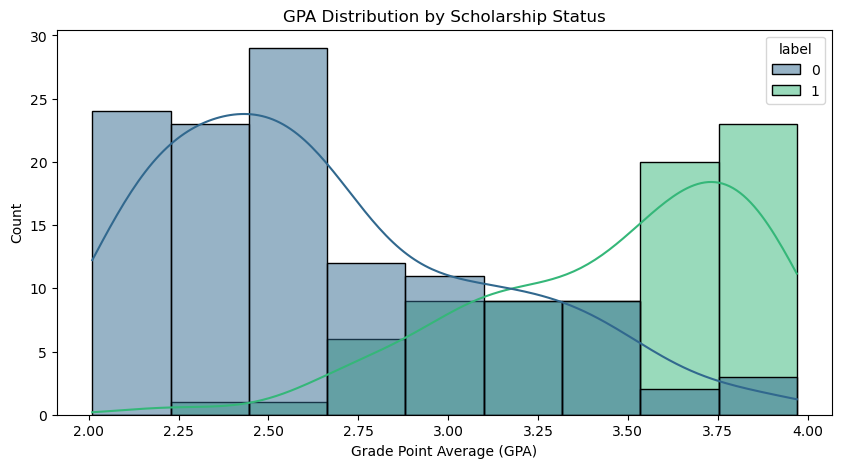

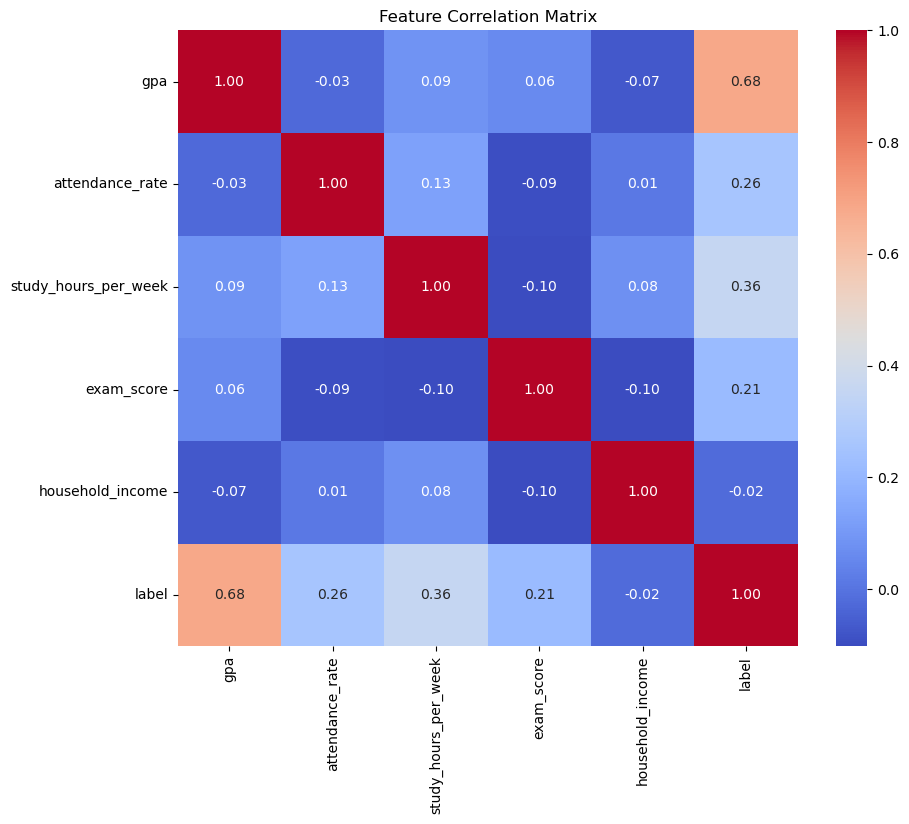

In [22]:
# Visualize GPA distribution relative to Scholarship (Label)
plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='gpa', hue='label', kde=True, palette='viridis')
plt.title('GPA Distribution by Scholarship Status')
plt.xlabel('Grade Point Average (GPA)')
plt.ylabel('Count')
plt.show()

# Correlation Matrix to identify important features
plt.figure(figsize=(10, 8))
sns.heatmap(train.drop('id', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

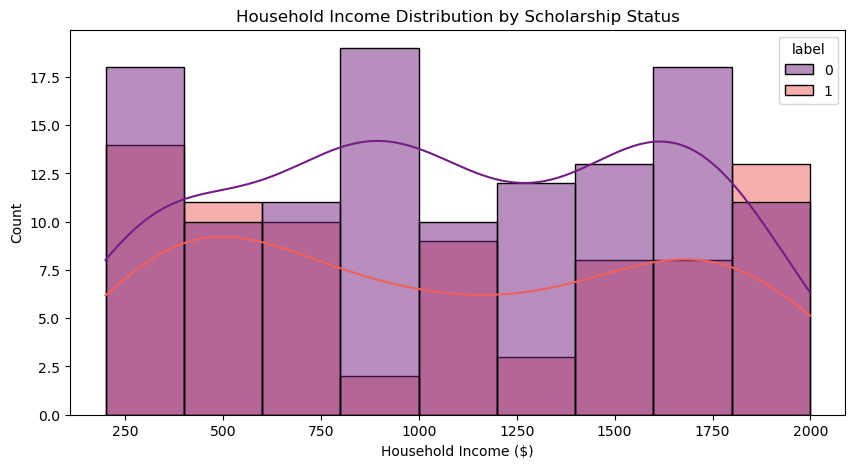

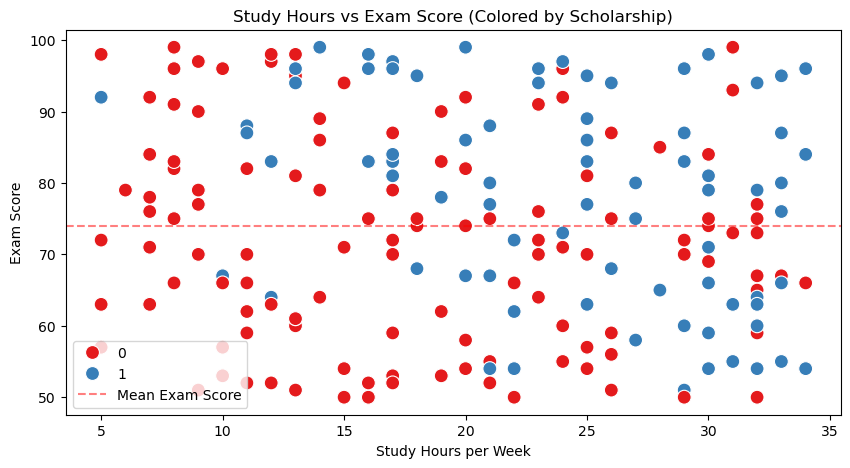

In [23]:
# Visualize Household Income distribution relative to Scholarship
plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='household_income', hue='label', kde=True, palette='magma')
plt.title('Household Income Distribution by Scholarship Status')
plt.xlabel('Household Income ($)')
plt.ylabel('Count')
plt.show()

# Visualize the interaction between Study Hours and Exam Score
plt.figure(figsize=(10, 5))
sns.scatterplot(data=train, x='study_hours_per_week', y='exam_score', hue='label', palette='Set1', s=100)
plt.title('Study Hours vs Exam Score (Colored by Scholarship)')
plt.xlabel('Study Hours per Week')
plt.ylabel('Exam Score')
plt.axhline(y=train['exam_score'].mean(), color='r', linestyle='--', alpha=0.5, label='Mean Exam Score')
plt.legend()
plt.show()

### Justification for Preprocessing Decisions
- **Feature Engineering (Interaction terms):** Creating new features like `gpa_attendance` and `study_exam` is based on the hypothesis that the combination of academic performance and attendance, or study time and test scores, will have a stronger synergistic effect on the probability of receiving a scholarship than considering each factor individually.
- **Feature Scaling:** `StandardScaler` (instead of MinMaxScaler) was chosen because models like Logistic Regression converge better and are not biased by features with large magnitudes (such as `household_income`) when all features are standardized to a normal distribution (mean=0, variance=1).

In [24]:
# Feature Engineering: Creating interaction terms [cite: 31]
def add_features(df):
    df = df.copy()
    # Interaction between academic performance and attendance
    df['gpa_attendance'] = df['gpa'] * df['attendance_rate']
    # Interaction between study habits and exam results
    df['study_exam'] = df['study_hours_per_week'] * df['exam_score']
    return df

train = add_features(train)
dev   = add_features(dev)
test  = add_features(test)

# Prepare Features (X) and Target (y)
X_train = train.drop(['id', 'label'], axis=1)
y_train = train['label']
X_dev   = dev.drop(['id', 'label'], axis=1)
y_dev   = dev['label']
X_test  = test.drop(['id', 'label'], axis=1)

# Feature Scaling: Normalization for better convergence [cite: 30]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled   = scaler.transform(X_dev)
X_test_scaled  = scaler.transform(X_test)

In [25]:
# 4.1 Logistic Regression (Baseline)
lr = LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')
grid_lr = GridSearchCV(lr, {'C': [0.1, 1, 10, 50]}, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

# 4.2 Random Forest (Advanced)
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
}, cv=5, scoring='f1')
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_



--- Logistic Regression Performance ---
Accuracy:  0.9750
Precision: 0.9412
Recall:    1.0000
F1 Score:  0.9697


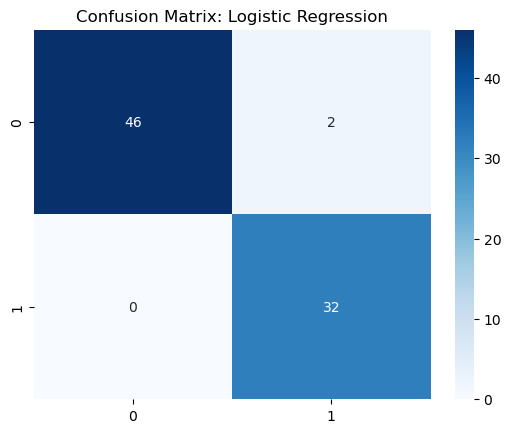


--- Random Forest Performance ---
Accuracy:  0.9500
Precision: 0.9375
Recall:    0.9375
F1 Score:  0.9375


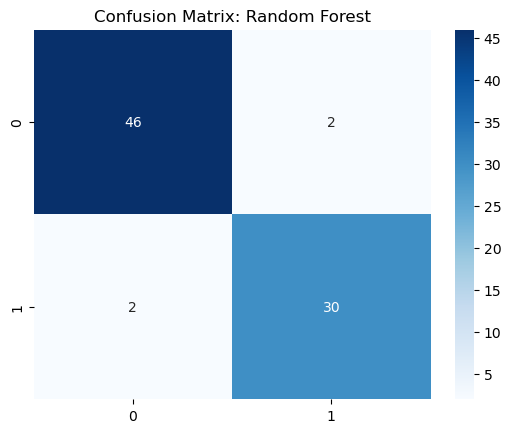


Total misclassified samples on Dev set: 2


,id,gpa,attendance_rate,study_hours_per_week,exam_score,household_income,label,gpa_attendance,study_exam,predicted
17,18,2.91,0.77,21,96,1742,0,2.2407,2016,1
66,67,3.58,0.94,6,73,1673,0,3.3652,438,1


In [26]:
def evaluate_model(model, X, y, name):
    pred = model.predict(X)
    print(f"\n--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y, pred):.4f}")
    print(f"Precision: {precision_score(y, pred, zero_division=0):.4f}") # Dòng mới bổ sung
    print(f"Recall:    {recall_score(y, pred, zero_division=0):.4f}")    # Dòng mới bổ sung
    print(f"F1 Score:  {f1_score(y, pred):.4f}")
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    return pred

# Execute evaluation
y_dev_pred_lr = evaluate_model(best_lr, X_dev_scaled, y_dev, "Logistic Regression")
y_dev_pred_rf = evaluate_model(best_rf, X_dev_scaled, y_dev, "Random Forest")

# ERROR ANALYSIS: Identifying misclassified samples [cite: 45-46, 115-116]
dev_errors = dev.copy()
dev_errors['predicted'] = y_dev_pred_lr
errors = dev_errors[dev_errors['label'] != dev_errors['predicted']]
print(f"\nTotal misclassified samples on Dev set: {len(errors)}")
display(errors.head())

### Error Analysis
After reviewing the prediction results of the Logistic Regression model on the Development Set, we observed a few cases where the model made incorrect predictions (e.g., predicted to receive a scholarship [1] but actually did not [0]):

1. **Sample ID 18:** This student has an extremely high `exam_score` (96) and a large number of `study_hours_per_week` (21 hours). The model was misled by this excellent academic performance. However, their `household_income` is extremely high ($1742). The scholarship criteria seem to have a hard threshold to filter out students from wealthy families, which the linear model failed to penalize strongly enough.
2. **Sample ID 67:** Similarly, the student has an excellent `gpa` (3.58) and a very high `attendance_rate` (0.94). But the family income is also at a very high level ($1673) and self-study time is very low (6 hours). 

**Conclusion & Recommendations for Improvement:** Linear models sometimes struggle with hard-threshold decision rules (e.g., "If income > $1600, automatically reject"). In the future, we could improve this by *binning* the `household_income` feature into categorical groups (High, Medium, Low) so that the model can capture this rule more easily.

In [27]:
# Using the best performing model (Logistic Regression) for the hidden test set
final_pred = best_lr.predict(X_test_scaled)

# Creating the submission file with required format: id,label_pred [cite: 94-98]
submission = pd.DataFrame({'label_pred': final_pred})
# Ensure index matches required sequence (1, 2, 3...)
submission.index = np.arange(1, len(submission) + 1)
submission.to_csv('predictions.csv', index=True, index_label='id')

print("Submission file 'predictions.csv' generated successfully.")

Submission file 'predictions.csv' generated successfully.
